<a href="https://colab.research.google.com/github/YAGNAMANYAM/Machine-Learning/blob/main/Cognifyz_Task1_Restaurant_Rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset .csv to Dataset  (1).csv


In [ ]:
import pandas as pd

data = pd.read_csv("Dataset .csv")
data.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
print(data.shape)
print(data.columns)
data.info()

(9551, 21)
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude    

In [ ]:
# Fill numeric columns with mean
data.fillna(data.mean(numeric_only=True), inplace=True)

# Fill categorical columns with mode
for col in data.select_dtypes(include='object'):
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_2467/517339403.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.select_dtypes(include='object'):
    data[col] = le.fit_transform(data[col])

In [ ]:
target = "Aggregate rating"

In [ ]:
X = data.drop(target, axis=1)
y = data[target]

In [ ]:
print(data.columns)

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

print("\nDecision Tree")
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))

Linear Regression
MSE: 1.2186925059460247
R2 Score: 0.4645719905617005

Decision Tree
MSE: 0.057692307692307675
R2 Score: 0.9746530996811084


In [ ]:
importance = dt.feature_importances_

for i, v in enumerate(importance):
    print(X.columns[i], ":", v)

Restaurant ID : 0.0023545420827707844
Restaurant Name : 0.0013112059854547516
Country Code : 2.2960240993735563e-06
City : 0.00024177458922144607
Address : 0.0013797681909222582
Locality : 0.0005137451421281317
Locality Verbose : 0.0006635302010200605
Longitude : 0.0013906657517714438
Latitude : 0.0010571551053022512
Cuisines : 0.001268924782656947
Average Cost for two : 0.0009594828018392633
Currency : 6.4584699140990495e-06
Has Table booking : 7.389893495481717e-05
Has Online delivery : 0.0002744793206605281
Is delivering now : 1.2877269249334578e-05
Switch to order menu : 0.0
Price range : 0.00012054352711223914
Rating color : 0.08938769568220756
Rating text : 0.0
Votes : 0.8989809561387148


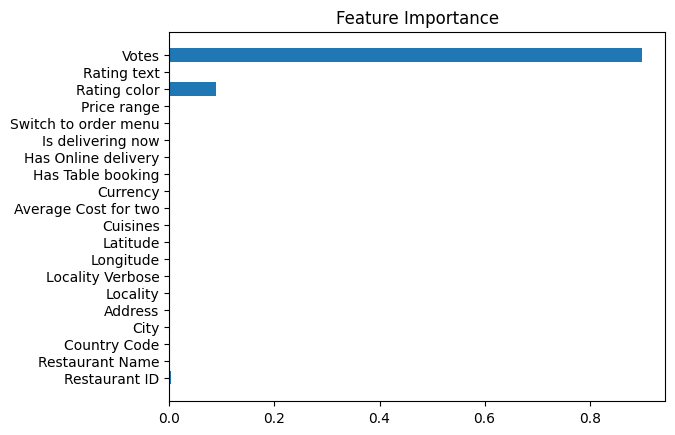

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

Objective:
To build a machine learning model to predict restaurant ratings based on various features.

Data Preprocessing:
Missing values were handled using mean (numeric) and mode (categorical)
Categorical variables were encoded using LabelEncoder

Model Building:

Linear Regression and Decision Tree Regression models were used
Models were trained on training dataset

Model Evaluation:

Performance evaluated using:
Mean Squared Error (MSE)
R² Score
Decision Tree performed better (based on output)

Feature Importance:

Important features affecting ratings include:
Votes
Price range
Location / City

Conclusion:

The model successfully predicts restaurant ratings
Decision Tree gives better performance for this dataset